<a href="https://colab.research.google.com/github/Mmbsaksd/fine_tuning/blob/master/Distill_BERT_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Classification using DistillBERT

In [1]:
# ============================================================
# Package Installation with UV (2026 standard)
# ============================================================
# Works in Google Colab (--system) and in a local uv venv.
# Locally you can also run: uv pip install <packages> in your terminal.
# import sys
# import subprocess

# IS_COLAB = "google.colab" in sys.modules

# def uv_install(*packages):
#     """Install packages with uv (adds --system automatically in Colab)."""
#     cmd = ["uv", "pip", "install"] + (["--system"] if IS_COLAB else []) + list(packages)
#     print(" ".join(cmd))
#     subprocess.run(cmd, check=True)

# uv_install(
#     "transformers",   # 5.x — latest
#     "datasets",       # 5.x — latest
#     "evaluate",
#     "accelerate",
#     "seqeval",
#     "matplotlib",
#     "seaborn",
#     "scikit-learn",
#     "pandas",
#     "numpy",
#     # "torch",        # uncomment locally if torch is missing (Colab ships it)
# )
# print("✅ All packages installed successfully!")

In [2]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


In [3]:
# ============================================================
# Library Import Verification - FIXED
# ============================================================

import sys

def check_import(library_name, version_attr="__version__"):  # ✅ Removed unused import_statement
    try:
        module = __import__(library_name)
        version = getattr(module, version_attr, "version unknown")
        print(f"✅ {library_name:<20} version: {version}")
        return True
    except ImportError as e:
        print(f"❌ {library_name:<20} FAILED - {e}")
        return False

print("=" * 55)
print("       Library Import Verification Check")
print("=" * 55)
print(f"Python version: {sys.version}\n")

results = {}

# --- Core Libraries ---
print("📦 Core Libraries:")
results["transformers"]   = check_import("transformers")
results["datasets"]       = check_import("datasets")
results["evaluate"]       = check_import("evaluate")
results["accelerate"]     = check_import("accelerate")

# --- Evaluation ---
# print("\n📊 Evaluation:")
# try:
#     import seqeval
#     print(f"✅ {'seqeval':<20} imported successfully")
#     results["seqeval"] = True
# except ImportError as e:
#     print(f"❌ {'seqeval':<20} FAILED - {e}")
#     results["seqeval"] = False

# --- Visualization ---
print("\n🎨 Visualization:")
results["matplotlib"]     = check_import("matplotlib")
results["seaborn"]        = check_import("seaborn")

# --- Data & ML ---
print("\n🔢 Data & ML:")
results["sklearn"]        = check_import("sklearn")
results["pandas"]         = check_import("pandas")
results["numpy"]          = check_import("numpy")

# --- Deep Learning ---
print("\n🤖 Deep Learning:")
try:
    import torch
    print(f"✅ {'torch':<20} version: {torch.__version__}")
    print(f"   CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
    results["torch"] = True
except ImportError as e:
    print(f"❌ {'torch':<20} FAILED - {e}")
    results["torch"] = False

# --- Summary ---
print("\n" + "=" * 55)
passed = sum(results.values())
total  = len(results)

if passed == total:
    print(f"✅ All {total}/{total} libraries imported successfully!")
else:
    print(f"⚠️  {passed}/{total} libraries passed")
    failed = [lib for lib, ok in results.items() if not ok]
    print(f"❌ Failed libraries: {', '.join(failed)}")
    print("\n💡 Fix failed installs with:")
    for lib in failed:
        print(f"   !uv pip install {lib}")

print("=" * 55)


       Library Import Verification Check
Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]

📦 Core Libraries:
✅ transformers         version: 5.16.1
✅ datasets             version: 4.8.5
✅ evaluate             version: 0.4.6
✅ accelerate           version: 1.14.0

🎨 Visualization:
✅ matplotlib           version: 3.10.0
✅ seaborn              version: 0.13.2

🔢 Data & ML:
✅ sklearn              version: 1.6.1
✅ pandas               version: 2.2.3
✅ numpy                version: 2.1.3

🤖 Deep Learning:
✅ torch                version: 2.11.0+cu128
   CUDA available: True
   GPU: Tesla T4

✅ All 10/10 libraries imported successfully!


### Import Libraries

In [4]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Machine learning
from sklearn.metrics import classification_report, confusion_matrix

# Hugging Face libraries
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
from datasets import load_dataset
import evaluate

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### Configuration

In [5]:
# Model configuration
MODEL_NAME = "distilbert-base-uncased"  # Fast and efficient model
# MODEL_NAME = "answerdotai/ModernBERT-base"  # State-of-the-art (requires more memory)

# Dataset configuration
DATASET_NAME = "cardiffnlp/tweet_sentiment_multilingual"
DATASET_SUBSET = "english"  # Options: english, spanish, french, german, etc.

# Training hyperparameters (2026 standards)
LEARNING_RATE = 2e-5      # Standard for BERT models
BATCH_SIZE = 32         # Batch size for training
NUM_EPOCHS = 3            # Number of training epochs
WEIGHT_DECAY = 0.01       # Regularization
MAX_LENGTH = 128          # Maximum sequence length

# Label configuration
LABEL_NAMES = ["negative", "neutral", "positive"]
NUM_LABELS = len(LABEL_NAMES)

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"Model: {MODEL_NAME}")
print(f"Dataset: {DATASET_NAME} ({DATASET_SUBSET})")
print(f"Number of classes: {NUM_LABELS}")
print(f"Labels: {LABEL_NAMES}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print("=" * 60)

CONFIGURATION
Model: distilbert-base-uncased
Dataset: cardiffnlp/tweet_sentiment_multilingual (english)
Number of classes: 3
Labels: ['negative', 'neutral', 'positive']
Learning rate: 2e-05
Batch size: 32
Epochs: 3


## Dataset Loading

In [6]:
# Optional: Hugging Face authentication (only needed for gated datasets/models)
# In Colab: add HF_TOKEN via Secrets (🔑). Locally: set it below or use `huggingface-cli login`.
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN_WRITE')
    print("✅ Loaded HF_TOKEN from Colab secrets")
except Exception:
    HF_TOKEN = None  # public datasets work without a token


✅ Loaded HF_TOKEN from Colab secrets


In [7]:
print("Loading dataset...")
# datasets 5.x no longer supports dataset loading scripts, so we load the
# Hub's official parquet export (refs/convert/parquet) — identical data.
dataset = load_dataset(
    DATASET_NAME,
    revision="refs/convert/parquet",
    data_dir=DATASET_SUBSET,  # language folder, e.g. "english"
)

print("\n✅ Dataset loaded successfully!\n")
print("Dataset structure:")
print(dataset)

Loading dataset...


0000.parquet:   0%|          | 0.00/155k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/29.1k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/64.8k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]


✅ Dataset loaded successfully!

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1839
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 324
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 870
    })
})


In [8]:
# Convert to pandas DataFrame for easier exploration
train_df = dataset['train'].to_pandas()
val_df = dataset['validation'].to_pandas()
test_df = dataset['test'].to_pandas()

print("Dataset Sizes:")
print(f"  Training set:   {len(train_df)} samples")
print(f"  Validation set: {len(val_df)} samples")
print(f"  Test set:       {len(test_df)} samples")

print("\nClass Distribution (Training Set):")
class_dist = train_df['label'].value_counts().sort_index()
for i, count in enumerate(class_dist):
    print(f"  {LABEL_NAMES[i]:10s}: {count:4d} samples ({100*count/len(train_df):.1f}%)")

Dataset Sizes:
  Training set:   1839 samples
  Validation set: 324 samples
  Test set:       870 samples

Class Distribution (Training Set):
  negative  :  613 samples (33.3%)
  neutral   :  613 samples (33.3%)
  positive  :  613 samples (33.3%)


### Visualize Class Distribution

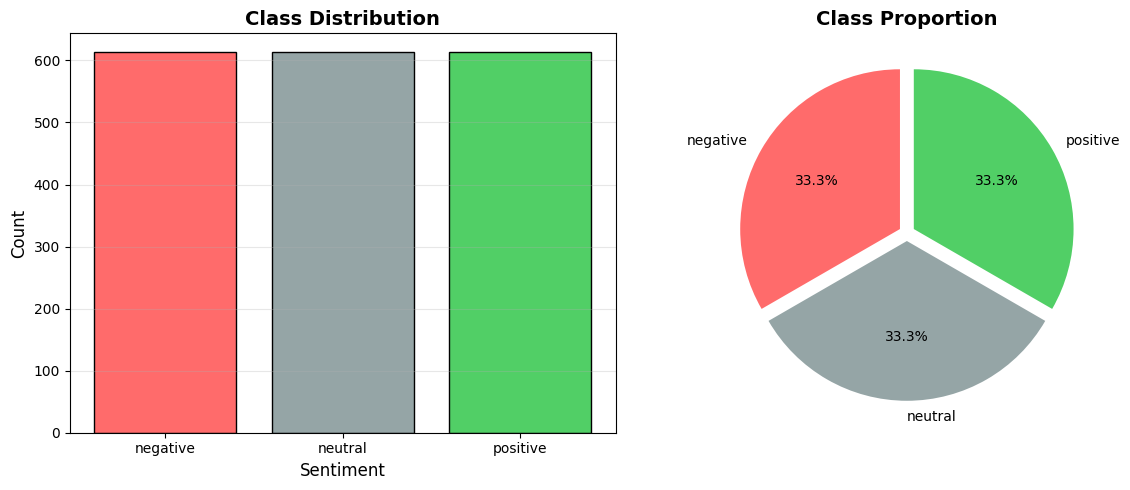


📊 Visualization saved as 'class_distribution.png'


In [9]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
axes[0].bar(LABEL_NAMES, train_df['label'].value_counts().sort_index(),
            color=['#ff6b6b', '#95a5a6', '#51cf66'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
sizes = train_df['label'].value_counts().sort_index().values
axes[1].pie(sizes, labels=LABEL_NAMES, autopct='%1.1f%%',
            colors=['#ff6b6b', '#95a5a6', '#51cf66'],
            explode=(0.05, 0.05, 0.05), startangle=90)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Visualization saved as 'class_distribution.png'")

## Dataset Samples

In [10]:
print("Sample Examples from Training Set:")
print("=" * 80)

# Show examples from each class
for class_id in range(NUM_LABELS):
    sample_idx = train_df[train_df['label'] == class_id].index[0]
    example = dataset['train'][int(sample_idx)]  # Convert numpy.int64 to int

    print(f"\nClass: {LABEL_NAMES[class_id].upper()}")
    print(f"Text: \"{example['text'][:100]}...\"")
    print("-" * 80)

Sample Examples from Training Set:

Class: NEGATIVE
Text: "okay i\u2019m sorry but TAYLOR SWIFT LOOKS NOTHING LIKE JACKIE O SO STOP COMPARING THE TWO. c\u2019m..."
--------------------------------------------------------------------------------

Class: NEUTRAL
Text: "@user the DC comics site has Batman 44 releases on the 9th but its out now? ..."
--------------------------------------------------------------------------------

Class: POSITIVE
Text: ""Frank Gaffrey\u002c Cliff May\u002c Steve Emerson: Brilliant. \""""Looming Threats: Iran\u002c Hezb..."
--------------------------------------------------------------------------------


### Tokenizer

In [11]:
# Load tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.model_max_length = MAX_LENGTH

print(f"\n✅ Tokenizer loaded!")
print(f"   Vocabulary size: {tokenizer.vocab_size:,}")
print(f"   Max sequence length: {tokenizer.model_max_length}")

Loading tokenizer: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


✅ Tokenizer loaded!
   Vocabulary size: 30,522
   Max sequence length: 128


### Tokenization

In [12]:
def tokenize_function(examples):
    """
    Tokenize text examples for BERT.

    Args:
        examples: Dictionary with 'text' key

    Returns:
        Tokenized inputs (input_ids, attention_mask, etc.)
    """
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

print("✅ Tokenization function defined!")

✅ Tokenization function defined!


In [13]:
print("Tokenizing dataset (this may take a minute)...\n")

# Tokenize all splits
tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,
    desc="Tokenizing"
)

# Remove the original text column (not needed after tokenization)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

# Rename 'label' to 'labels' (Trainer expects this name)
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# Set format to PyTorch tensors
tokenized_datasets.set_format("torch")

print("\n✅ Tokenization complete!")
print(f"\nTokenized dataset features: {list(tokenized_datasets['train'].features.keys())}")

Tokenizing dataset (this may take a minute)...



Tokenizing:   0%|          | 0/1839 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/324 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/870 [00:00<?, ? examples/s]


✅ Tokenization complete!

Tokenized dataset features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [14]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1839
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 324
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 870
    })
})

In [15]:
tokenized_datasets['train'][0]

{'labels': tensor(0),
 'input_ids': tensor([  101,  3100,  1045,  1032, 23343, 24096,  2683,  2213,  3374,  2021,
          4202,  9170,  3504,  2498,  2066,  9901,  1051,  2061,  2644, 13599,
          1996,  2048,  1012,  1039,  1032, 23343, 24096,  2683,  8202,  2637,
          4995,  1032, 23343, 24096,  2683,  2102,  2017,  5305,  1997,  2014,
          2664,  1029,  1006,  3374,  1007,   102,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,  

In [16]:
# Check a tokenized example
sample = tokenized_datasets['train'][0]

print("Sample Tokenized Example:")
print("=" * 60)
print(f"Input IDs shape: {sample['input_ids'].shape}")
print(f"Attention Mask shape: {sample['attention_mask'].shape}")
print(f"Label: {sample['labels']} ({LABEL_NAMES[sample['labels']]})")
print(f"\nFirst 20 input IDs: {sample['input_ids'][:20].tolist()}")
print(f"First 20 attention mask: {sample['attention_mask'][:20].tolist()}")

Sample Tokenized Example:
Input IDs shape: torch.Size([128])
Attention Mask shape: torch.Size([128])
Label: 0 (negative)

First 20 input IDs: [101, 3100, 1045, 1032, 23343, 24096, 2683, 2213, 3374, 2021, 4202, 9170, 3504, 2498, 2066, 9901, 1051, 2061, 2644, 13599]
First 20 attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [17]:
# ============================================================
# Device Selection — local Apple Silicon (MPS) or Colab GPU (CUDA)
# ============================================================
import torch

FORCE_DEVICE = "cuda"   # <-- set "cuda" for Colab GPU, "mps" for Apple Silicon, None = auto

def pick_device():
    if FORCE_DEVICE:
        return torch.device(FORCE_DEVICE)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = pick_device()

print("=" * 60)
print("DEVICE CONFIGURATION")
print("=" * 60)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available:  {torch.backends.mps.is_available()}")

if device.type == "cuda":
    print(f"\n✅ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"   BF16 supported: {torch.cuda.is_bf16_supported()}")
elif device.type == "mps":
    print("\n✅ Apple Silicon GPU detected — using MPS acceleration")
else:
    print("\n⚠️ No GPU detected. Training will run on CPU (slower).")
    print("   Colab: Runtime > Change runtime type > T4 GPU")

print(f"\n📍 Using device: {device}")
print("=" * 60)


DEVICE CONFIGURATION
PyTorch version: 2.11.0+cu128
CUDA available: True
MPS available:  False

✅ GPU detected: Tesla T4
   GPU memory: 15.64 GB
   BF16 supported: True

📍 Using device: cuda


In [18]:
# Create label mappings
label2id = {label: i for i, label in enumerate(LABEL_NAMES)}
id2label = {i: label for i, label in enumerate(LABEL_NAMES)}

print(f"Loading model: {MODEL_NAME}")
print("(This downloads the pre-trained model weights...)\n")

# Load model with classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

# Move model to GPU if available
model.to(device)

print(f"\n✅ Model loaded successfully!")

Loading model: distilbert-base-uncased
(This downloads the pre-trained model weights...)



model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Model loaded successfully!
